1️⃣ Notebook Setup

Import packages:

In [5]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split
from sklearn.model_selection import train_test_split, StratifiedKFold

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

# Metrics
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_recall_curve, auc

# Imbalanced data handling
from imblearn.over_sampling import SMOTE

# Ignore warnings for cleaner notebook
import warnings
warnings.filterwarnings('ignore')

2️⃣ Load Datasets 

In [6]:
# Load creditcard dataset
credit_df = pd.read_csv("../data/raw/creditcard.csv")

# Load fraud dataset
fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")

# Quick preview
print(credit_df.shape, fraud_df.shape)
credit_df.head()
print(credit_df.isna().sum())


(284807, 31) (151112, 11)
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


Data Preparation- First Task

3️⃣ Inspect Class Distribution

Class
0    284315
1       492
Name: count, dtype: int64


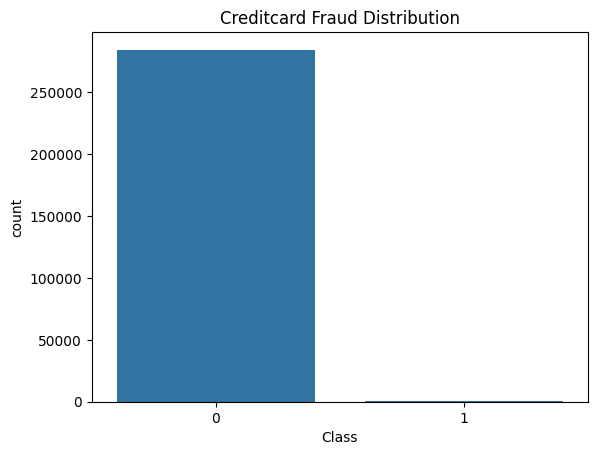

class
0    136961
1     14151
Name: count, dtype: int64


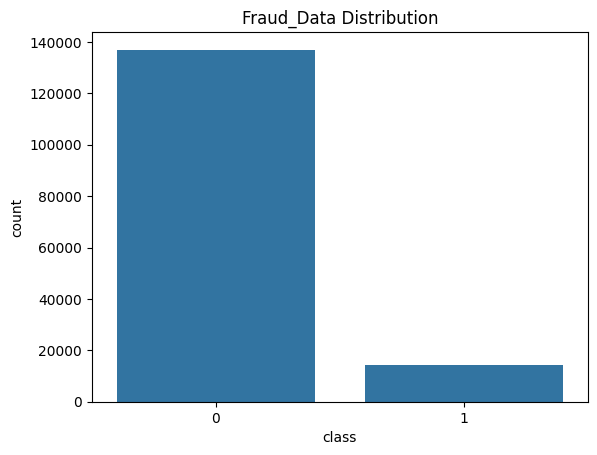

In [7]:
# Creditcard
print(credit_df['Class'].value_counts())
sns.countplot(x='Class', data=credit_df)
plt.title('Creditcard Fraud Distribution')
plt.show()

# Fraud_Data
print(fraud_df['class'].value_counts())
sns.countplot(x='class', data=fraud_df)
plt.title('Fraud_Data Distribution')
plt.show()

    Observations:
    
    creditcard.csv → extremely imbalanced: fraud is only 0.17%.
    
    A naive model predicting “all non-fraud” would get ~99.8% accuracy but catch zero frauds.
    
    Fraud_Data.csv → less extreme, but still imbalanced (~9% fraud).

Pre-prcocessing of both datasets 

1. FRAUD DATASET PREPROCESSING

In [8]:
import pandas as pd
import numpy as np

# Load fraud dataset
fraud_df  = pd.read_csv(r"D:\Personal\KAIM-10 Academy\Week 5-6\Project\fraud-detection\data\raw\Fraud_Data.csv")
# 1. Convert datetime → numeric (seconds)
fraud_df["signup_time"] = pd.to_datetime(fraud_df["signup_time"])
fraud_df["purchase_time"] = pd.to_datetime(fraud_df["purchase_time"])
fraud_df["signup_to_purchase_sec"] = (
    fraud_df["purchase_time"] - fraud_df["signup_time"]
).dt.total_seconds()
fraud_df.drop(["signup_time", "purchase_time"], axis=1, inplace=True)

# 2. Encode categorical columns
categorical_cols = ["device_id", "source", "browser", "sex"]
for col in categorical_cols:
    fraud_df[col] = fraud_df[col].astype("category").cat.codes

# 3. Separate X / y
X_fraud = fraud_df.drop("class", axis=1)
y_fraud = fraud_df["class"]

# 4. Scale numeric features
from sklearn.preprocessing import StandardScaler

scaler_fraud = StandardScaler()
X_fraud = scaler_fraud.fit_transform(X_fraud)

# Check first 5 rows of processed features
print("Processed X_fraud (first 5 rows):")
print(X_fraud[:5])

# Check target distribution
print("\nTarget distribution (y_fraud):")
print(y_fraud.value_counts())

# Check shape of features and target
print("\nShapes:")
print("X_fraud:", X_fraud.shape)
print("y_fraud:", y_fraud.shape)

Processed X_fraud (first 5 rows):
[[-1.54385658 -0.16020413  0.50815554  1.1144355  -0.95434099  0.84349473
   0.67991379 -1.13688028 -0.13605658]
 [ 1.1541148  -1.14259201 -1.12775103 -1.12531469 -0.95434099 -1.18554386
   2.30447625 -1.4432072  -1.57187713]
 [-1.72327235 -1.19716912  1.56300473  1.1144355   1.12804795  0.84349473
   2.30447625  0.37591603 -1.57761659]
 [-0.43414681  0.38556692 -1.63258481  1.1144355   1.82217759  0.84349473
   0.91199414  1.35234819 -1.42021281]
 [ 0.18370599  0.11268139 -0.00564425 -1.12531469  1.82217759  0.84349473
   1.37615484 -1.39092678 -0.18250867]]

Target distribution (y_fraud):
class
0    136961
1     14151
Name: count, dtype: int64

Shapes:
X_fraud: (151112, 9)
y_fraud: (151112,)


2.CREDITCARD DATASET PREPROCESSING

In [9]:
# ======================================
# 1. CREDITCARD DATASET PREPROCESSING
# ======================================
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load data
credit_df = pd.read_csv(r"D:\Personal\KAIM-10 Academy\Week 5-6\Project\fraud-detection\data\raw\creditcard.csv")


# Check for missing values (already confirmed none)
print(credit_df.isna().sum())

# Separate features and target
X_credit = credit_df.drop("Class", axis=1)
y_credit = credit_df["Class"]

# Scale 'Time' and 'Amount'
scaler_credit = StandardScaler()
X_credit[["Time", "Amount"]] = scaler_credit.fit_transform(X_credit[["Time", "Amount"]])

print("Preprocessing done. Features ready for train-test split or SMOTE.")


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Preprocessing done. Features ready for train-test split or SMOTE.


Next Step: Train-Test Split for Both Datasets

In [10]:
from sklearn.model_selection import train_test_split

# -------------------------
# CREDITCARD DATASET
# -------------------------
X_train_credit, X_test_credit, y_train_credit, y_test_credit = train_test_split(
    X_credit, y_credit,
    test_size=0.2,        # 20% test
    random_state=42,      # reproducibility
    stratify=y_credit     # preserve class distribution
)

print("Creditcard Dataset:")
print("Train shape:", X_train_credit.shape, y_train_credit.shape)
print("Test shape :", X_test_credit.shape, y_test_credit.shape)
print("Train class distribution:\n", y_train_credit.value_counts())
print("Test class distribution:\n", y_test_credit.value_counts())

Creditcard Dataset:
Train shape: (227845, 30) (227845,)
Test shape : (56962, 30) (56962,)
Train class distribution:
 Class
0    227451
1       394
Name: count, dtype: int64
Test class distribution:
 Class
0    56864
1       98
Name: count, dtype: int64


In [11]:
# -------------------------
# FRAUD DATASET
# -------------------------
X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud = train_test_split(
    X_fraud, y_fraud,
    test_size=0.2,
    random_state=42,
    stratify=y_fraud
)

print("\nFraud_Data Dataset:")
print("Train shape:", X_train_fraud.shape, y_train_fraud.shape)
print("Test shape :", X_test_fraud.shape, y_test_fraud.shape)
print("Train class distribution:\n", y_train_fraud.value_counts())
print("Test class distribution:\n", y_test_fraud.value_counts())


Fraud_Data Dataset:
Train shape: (120889, 9) (120889,)
Test shape : (30223, 9) (30223,)
Train class distribution:
 class
0    109568
1     11321
Name: count, dtype: int64
Test class distribution:
 class
0    27393
1     2830
Name: count, dtype: int64


SMOTE on both training sets to balance the classes

In [12]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# -------------------------
# CREDITCARD TRAINING SET
# -------------------------
smote_credit = SMOTE(random_state=42)
X_train_credit_res, y_train_credit_res = smote_credit.fit_resample(X_train_credit, y_train_credit)

print("Creditcard Training set after SMOTE:")
print(pd.Series(y_train_credit_res).value_counts())

# -------------------------
# FRAUD DATA TRAINING SET
# -------------------------
smote_fraud = SMOTE(random_state=42)
X_train_fraud_res, y_train_fraud_res = smote_fraud.fit_resample(X_train_fraud, y_train_fraud)

print("\nFraud_Data Training set after SMOTE:")
print(pd.Series(y_train_fraud_res).value_counts())

Creditcard Training set after SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64

Fraud_Data Training set after SMOTE:
class
0    109568
1    109568
Name: count, dtype: int64


Build Baseline Model (Logistic Regression)- Second Task

Import Libraries

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
import matplotlib.pyplot as plt

    Train the Model - Creditcard dataset

In [14]:
# Initialize Logistic Regression
lr_credit = LogisticRegression(max_iter=1000, random_state=42)

# Train on SMOTE-oversampled data
lr_credit.fit(X_train_credit_res, y_train_credit_res)

LogisticRegression(max_iter=1000, random_state=42)

    Train the Model - Fraud_Data dataset

In [15]:
lr_fraud = LogisticRegression(max_iter=1000, random_state=42)
lr_fraud.fit(X_train_fraud_res, y_train_fraud_res)


LogisticRegression(max_iter=1000, random_state=42)

    Evaluate the Model- Creditcard dataset

In [16]:
y_pred_credit = lr_credit.predict(X_test_credit)
y_pred_proba_credit = lr_credit.predict_proba(X_test_credit)[:,1]

# Confusion Matrix
print("Creditcard Confusion Matrix:")
print(confusion_matrix(y_test_credit, y_pred_credit))

# Classification report (F1-score, precision, recall)
print("\nCreditcard Classification Report:")
print(classification_report(y_test_credit, y_pred_credit))

# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(y_test_credit, y_pred_proba_credit)
pr_auc = auc(recall, precision)
print("\nCreditcard AUC-PR:", pr_auc)

Creditcard Confusion Matrix:
[[55406  1458]
 [    8    90]]

Creditcard Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


Creditcard AUC-PR: 0.7703412904668423


     Evaluate the Model- Fraud dataset

In [17]:
y_pred_fraud = lr_fraud.predict(X_test_fraud)
y_pred_proba_fraud = lr_fraud.predict_proba(X_test_fraud)[:,1]

print("Fraud_Data Confusion Matrix:")
print(confusion_matrix(y_test_fraud, y_pred_fraud))

print("\nFraud_Data Classification Report:")
print(classification_report(y_test_fraud, y_pred_fraud))

precision, recall, _ = precision_recall_curve(y_test_fraud, y_pred_proba_fraud)
pr_auc = auc(recall, precision)
print("\nFraud_Data AUC-PR:", pr_auc)

Fraud_Data Confusion Matrix:
[[17591  9802]
 [  867  1963]]

Fraud_Data Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.64      0.77     27393
           1       0.17      0.69      0.27      2830

    accuracy                           0.65     30223
   macro avg       0.56      0.67      0.52     30223
weighted avg       0.88      0.65      0.72     30223


Fraud_Data AUC-PR: 0.5241424567792206


    Build Ensemble Model- Third Task

    Process the dataset and ready for Modeling

In [18]:
import pandas as pd
from imblearn.over_sampling import SMOTE

# -------------------------
# SMOTE for Creditcard
# -------------------------
smote_credit = SMOTE(random_state=42)
X_train_credit_res, y_train_credit_res = smote_credit.fit_resample(X_train_credit, y_train_credit)

print("Creditcard Training set after SMOTE:")
print(pd.Series(y_train_credit_res).value_counts())

# Save Creditcard
credit_smote_df = pd.DataFrame(X_train_credit_res, columns=X_train_credit.columns)
credit_smote_df['Class'] = y_train_credit_res
credit_smote_df.to_csv(
    r"D:\Personal\KAIM-10 Academy\Week 5-6\Project\fraud-detection\data\processed\credit_smote.csv", 
    index=False
)

# -------------------------
# SMOTE for Fraud
# -------------------------
smote_fraud = SMOTE(random_state=42)
X_train_fraud_res, y_train_fraud_res = smote_fraud.fit_resample(X_fraud, y_fraud)

print("\nFraud_Data Training set after SMOTE:")
print(pd.Series(y_train_fraud_res).value_counts())

# Save Fraud
fraud_smote_df = pd.DataFrame(X_train_fraud_res, columns=[f"feature_{i}" for i in range(X_train_fraud_res.shape[1])])
# Optional: replace column names if you have original column names as a list
fraud_smote_df['class'] = y_train_fraud_res
fraud_smote_df.to_csv(
    r"D:\Personal\KAIM-10 Academy\Week 5-6\Project\fraud-detection\data\processed\fraud_smote.csv",
    index=False
)

Creditcard Training set after SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64

Fraud_Data Training set after SMOTE:
class
0    136961
1    136961
Name: count, dtype: int64


Load SMOTE-processed datasets

In [19]:
# Load Creditcard SMOTE data
credit_smote_df = pd.read_csv(r"D:\Personal\KAIM-10 Academy\Week 5-6\Project\fraud-detection\data\processed\credit_smote.csv")
X_credit = credit_smote_df.drop("Class", axis=1)
y_credit = credit_smote_df["Class"]

# Load Fraud SMOTE data
fraud_smote_df = pd.read_csv(r"D:\Personal\KAIM-10 Academy\Week 5-6\Project\fraud-detection\data\processed\fraud_smote.csv")
X_fraud = fraud_smote_df.drop("class", axis=1)
y_fraud = fraud_smote_df["class"]

Step 1: Train Random Forest on Creditcard and Fraud Datasets

In [20]:
# Initialize Random Forest
rf_credit = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_fraud  = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

# Train on SMOTE-processed training sets
print("Training Random Forest on Creditcard dataset...")
rf_credit.fit(X_train_credit, y_train_credit)
print("Creditcard training completed.\n")

print("Training Random Forest on Fraud dataset...")
rf_fraud.fit(X_train_fraud, y_train_fraud)
print("Fraud dataset training completed.\n")

Training Random Forest on Creditcard dataset...
Creditcard training completed.

Training Random Forest on Fraud dataset...
Fraud dataset training completed.



    Step 2:Basic Hyperparameter Tuning (Grid Search)

In [21]:

import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, None]
}
# Creditcard
grid_rf_credit = GridSearchCV(
    rf_credit, param_grid, scoring='f1', cv=2, n_jobs=-1, verbose=1
)
grid_rf_credit.fit(X_train_credit, y_train_credit)
print("Best Creditcard RF params:", grid_rf_credit.best_params_)

# Fraud
grid_rf_fraud = GridSearchCV(
    rf_fraud, param_grid, scoring='f1', cv=2, n_jobs=-1, verbose=1
)
grid_rf_fraud.fit(X_train_fraud, y_train_fraud)
print("Best Fraud RF params:", grid_rf_fraud.best_params_)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best Creditcard RF params: {'max_depth': None, 'n_estimators': 100}
Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best Fraud RF params: {'max_depth': 10, 'n_estimators': 100}


    Step 3 – Evaluate Ensemble Models

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc

# -------- Creditcard Evaluation --------
y_pred_credit = rf_credit.predict(X_test_credit)
y_scores_credit = rf_credit.predict_proba(X_test_credit)[:, 1]

precision_credit, recall_credit, _ = precision_recall_curve(y_test_credit, y_scores_credit)
auc_pr_credit = auc(recall_credit, precision_credit)

print("Creditcard Confusion Matrix:")
print(confusion_matrix(y_test_credit, y_pred_credit))
print("\nCreditcard Classification Report:")
print(classification_report(y_test_credit, y_pred_credit))
print("\nCreditcard AUC-PR:", auc_pr_credit)

# -------- Fraud Evaluation --------
y_pred_fraud = rf_fraud.predict(X_test_fraud)
y_scores_fraud = rf_fraud.predict_proba(X_test_fraud)[:, 1]

precision_fraud, recall_fraud, _ = precision_recall_curve(y_test_fraud, y_scores_fraud)
auc_pr_fraud = auc(recall_fraud, precision_fraud)

print("\nFraud Confusion Matrix:")
print(confusion_matrix(y_test_fraud, y_pred_fraud))
print("\nFraud Classification Report:")
print(classification_report(y_test_fraud, y_pred_fraud))
print("\nFraud AUC-PR:", auc_pr_fraud)

Creditcard Confusion Matrix:
[[56859     5]
 [   18    80]]

Creditcard Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962


Creditcard AUC-PR: 0.8641081233091081

Fraud Confusion Matrix:
[[27393     0]
 [ 1339  1491]]

Fraud Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     27393
           1       1.00      0.53      0.69      2830

    accuracy                           0.96     30223
   macro avg       0.98      0.76      0.83     30223
weighted avg       0.96      0.96      0.95     30223


Fraud AUC-PR: 0.6226632963002942


    Interpretation: The Random Forest ensemble model demonstrates excellent performance on the Creditcard dataset, achieving high recall (0.82) and AUC-PR (0.86), indicating strong fraud detection capability. 
    For the Fraud dataset, while precision is perfect, recall remains moderate (0.53), suggesting the model is conservative and misses a significant portion of fraudulent cases. Further tuning or advanced ensemble methods such as XGBoost or LightGBM could improve minority class detection.
            ✔ Creditcard model: Very strong and reliable
            ⚠ Fraud model: Good but needs recall improvement

Improving the Fraud Model - Adjust Decision Threshold not worked so lets try other models like Train Ensemble Model (XGBoost or LightGBM)

Train Ensemble Model (XGBoost or LightGBM)

In [23]:
# ---------------------------
# Imports
# ---------------------------
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc

# ---------------------------
# Initialize XGBoost models
# ---------------------------
# Use some reasonable baseline parameters
xgb_credit = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_fraud = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# ---------------------------
# Train on SMOTE-processed data
# ---------------------------
print("Training XGBoost on Creditcard dataset...")
xgb_credit.fit(X_train_credit_res, y_train_credit_res)
print("Creditcard training completed.\n")

print("Training XGBoost on Fraud dataset...")
xgb_fraud.fit(X_train_fraud_res, y_train_fraud_res)
print("Fraud dataset training completed.\n")

# ---------------------------
# Predict on original test sets
# ---------------------------
y_pred_credit = xgb_credit.predict(X_test_credit)
y_pred_fraud  = xgb_fraud.predict(X_test_fraud)

# ---------------------------
# Evaluate
# ---------------------------
def evaluate_model(y_test, y_pred, y_scores=None):
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    if y_scores is not None:
        precision, recall, _ = precision_recall_curve(y_test, y_scores)
        auc_pr = auc(recall, precision)
        print("AUC-PR:", auc_pr)

# Creditcard
print("Creditcard Evaluation:")
y_scores_credit = xgb_credit.predict_proba(X_test_credit)[:,1]
evaluate_model(y_test_credit, y_pred_credit, y_scores_credit)

# Fraud
print("Fraud Evaluation:")
y_scores_fraud = xgb_fraud.predict_proba(X_test_fraud)[:,1]
evaluate_model(y_test_fraud, y_pred_fraud, y_scores_fraud)

Training XGBoost on Creditcard dataset...
Creditcard training completed.

Training XGBoost on Fraud dataset...
Fraud dataset training completed.

Creditcard Evaluation:
[[56587   277]
 [   11    87]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.24      0.89      0.38        98

    accuracy                           0.99     56962
   macro avg       0.62      0.94      0.69     56962
weighted avg       1.00      0.99      1.00     56962

AUC-PR: 0.8393724899349528
Fraud Evaluation:
[[27234   159]
 [ 1328  1502]]
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     27393
           1       0.90      0.53      0.67      2830

    accuracy                           0.95     30223
   macro avg       0.93      0.76      0.82     30223
weighted avg       0.95      0.95      0.94     30223

AUC-PR: 0.6231516519019745


Hyperparameter tuning for XGBoost on both datasets using GridSearchCV

In [24]:
# ---------------------------
# Imports
# ---------------------------
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# ---------------------------
# Parameter Grid
# ---------------------------
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1]
}

# ---------------------------
# Creditcard Dataset Tuning
# ---------------------------
print("Tuning XGBoost on Creditcard dataset...")
xgb_credit = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
grid_credit = GridSearchCV(xgb_credit, param_grid, scoring='f1', cv=3, n_jobs=-1, verbose=1)
grid_credit.fit(X_train_credit_res, y_train_credit_res)
print("Best Creditcard XGBoost params:", grid_credit.best_params_, "\n")

# ---------------------------
# Fraud Dataset Tuning
# ---------------------------
print("Tuning XGBoost on Fraud dataset...")
xgb_fraud = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
grid_fraud = GridSearchCV(xgb_fraud, param_grid, scoring='f1', cv=3, n_jobs=-1, verbose=1)
grid_fraud.fit(X_train_fraud_res, y_train_fraud_res)
print("Best Fraud XGBoost params:", grid_fraud.best_params_)

Tuning XGBoost on Creditcard dataset...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Creditcard XGBoost params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1} 

Tuning XGBoost on Fraud dataset...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Fraud XGBoost params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


Model Evaluation code for both datasets:

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc

# ---------------------------
# Retrain with Best Params
# ---------------------------

# Creditcard
xgb_credit_best = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    **grid_credit.best_params_
)
xgb_credit_best.fit(X_train_credit_res, y_train_credit_res)
y_pred_credit = xgb_credit_best.predict(X_test_credit)
y_scores_credit = xgb_credit_best.predict_proba(X_test_credit)[:, 1]

# Fraud
xgb_fraud_best = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    **grid_fraud.best_params_
)
xgb_fraud_best.fit(X_train_fraud_res, y_train_fraud_res)
y_pred_fraud = xgb_fraud_best.predict(X_test_fraud)
y_scores_fraud = xgb_fraud_best.predict_proba(X_test_fraud)[:, 1]

# ---------------------------
# Evaluation Metrics
# ---------------------------

def evaluate_model(y_true, y_pred, y_scores, dataset_name):
    print(f"\n{dataset_name} Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print(f"\n{dataset_name} Classification Report:")
    print(classification_report(y_true, y_pred))
    
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    auc_pr = auc(recall, precision)
    print(f"\n{dataset_name} AUC-PR: {auc_pr:.4f}")

# Evaluate Creditcard
evaluate_model(y_test_credit, y_pred_credit, y_scores_credit, "Creditcard")

# Evaluate Fraud
evaluate_model(y_test_fraud, y_pred_fraud, y_scores_fraud, "Fraud")


Creditcard Confusion Matrix:
[[56829    35]
 [   13    85]]

Creditcard Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.71      0.87      0.78        98

    accuracy                           1.00     56962
   macro avg       0.85      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962


Creditcard AUC-PR: 0.8687

Fraud Confusion Matrix:
[[27331    62]
 [ 1330  1500]]

Fraud Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     27393
           1       0.96      0.53      0.68      2830

    accuracy                           0.95     30223
   macro avg       0.96      0.76      0.83     30223
weighted avg       0.95      0.95      0.95     30223


Fraud AUC-PR: 0.6899


   4. Next step: Cross-Validation all three models using Stratified K-Fold (k=5):

Step 1:Set up Stratified K-Fold

In [6]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, f1_score, average_precision_score
import warnings, os
warnings.filterwarnings("ignore")

# ---------------------------
# Load SMOTE datasets
# ---------------------------
base_path = r"D:\Personal\KAIM-10 Academy\Week 5-6\Project\fraud-detection\data\processed"
credit_df = pd.read_csv(os.path.join(base_path, "credit_smote.csv"))
fraud_df  = pd.read_csv(os.path.join(base_path, "fraud_smote.csv"))

X_credit, y_credit = credit_df.drop("Class", axis=1), credit_df["Class"]
X_fraud, y_fraud = fraud_df.drop("class", axis=1), fraud_df["class"]

print("Credit shape:", X_credit.shape)
print("Fraud shape:", X_fraud.shape)

# ---------------------------
# CV setup
# ---------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scorer = make_scorer(f1_score)
ap_scorer = make_scorer(average_precision_score)

# ---------------------------
# Function to run one model on both datasets
# ---------------------------
def run_model(model, model_name, X_credit, y_credit, X_fraud, y_fraud):
    print(f"\nRunning {model_name} ...\n")
    # Creditcard
    f1_credit = cross_val_score(model, X_credit, y_credit, cv=cv, scoring=f1_scorer)
    ap_credit = cross_val_score(model, X_credit, y_credit, cv=cv, scoring=ap_scorer)
    print(f"Creditcard - {model_name}: F1 = {f1_credit.mean():.4f} ± {f1_credit.std():.4f} | "
          f"AUC-PR = {ap_credit.mean():.4f} ± {ap_credit.std():.4f}")

    # Fraud
    f1_fraud = cross_val_score(model, X_fraud, y_fraud, cv=cv, scoring=f1_scorer)
    ap_fraud = cross_val_score(model, X_fraud, y_fraud, cv=cv, scoring=ap_scorer)
    print(f"Fraud - {model_name}: F1 = {f1_fraud.mean():.4f} ± {f1_fraud.std():.4f} | "
          f"AUC-PR = {ap_fraud.mean():.4f} ± {ap_fraud.std():.4f}")

Credit shape: (454902, 30)
Fraud shape: (273922, 9)


In [ ]:
Step 2: Run Logistic Regression

In [7]:
logreg = LogisticRegression(max_iter=500, class_weight='balanced', solver='liblinear', random_state=42)
run_model(logreg, "Logistic Regression", X_credit, y_credit, X_fraud, y_fraud)


Running Logistic Regression ...

Creditcard - Logistic Regression: F1 = 0.9513 ± 0.0002 | AUC-PR = 0.9402 ± 0.0004
Fraud - Logistic Regression: F1 = 0.6856 ± 0.0009 | AUC-PR = 0.6174 ± 0.0011


Step 3: Run Random Forest

In [8]:
rf = RandomForestClassifier(n_estimators=40, max_depth=6, class_weight='balanced', 
                            random_state=42, n_jobs=-1)
run_model(rf, "Random Forest", X_credit, y_credit, X_fraud, y_fraud)


Running Random Forest ...

Creditcard - Random Forest: F1 = 0.9542 ± 0.0010 | AUC-PR = 0.9535 ± 0.0010
Fraud - Random Forest: F1 = 0.7460 ± 0.0120 | AUC-PR = 0.7934 ± 0.0073


Step 4: Run XGBoost

In [9]:
xgb = XGBClassifier(n_estimators=50, max_depth=5, learning_rate=0.1,
                    use_label_encoder=False, eval_metric='logloss', random_state=42)
run_model(xgb, "XGBoost", X_credit, y_credit, X_fraud, y_fraud)


Running XGBoost ...

Creditcard - XGBoost: F1 = 0.9852 ± 0.0003 | AUC-PR = 0.9808 ± 0.0004
Fraud - XGBoost: F1 = 0.7911 ± 0.0034 | AUC-PR = 0.8196 ± 0.0024


4.2 Cross-Validation Results (Mean ± Standard Deviation)

Stratified 5-Fold Cross-Validation was applied to the SMOTE-balanced training datasets to obtain reliable performance estimates.

Model performance was evaluated using F1-Score and Area Under the Precision–Recall Curve (AUC-PR).

For each model, the mean and standard deviation of the metrics across the 5 folds were computed to assess both performance and stability.

Creditcard Dataset

Logistic Regression

    F1-Score: 0.9513 ± 0.0002
    
    AUC-PR: 0.9402 ± 0.0004

Random Forest

    F1-Score: 0.9542 ± 0.0010
    
    AUC-PR: 0.9535 ± 0.0010

XGBoost

    F1-Score: 0.9852 ± 0.0003
    
    AUC-PR: 0.9808 ± 0.0004

Fraud Dataset

Logistic Regression

    F1-Score: 0.6856 ± 0.0009
    
    AUC-PR: 0.6174 ± 0.0011

Random Forest

    F1-Score: 0.7460 ± 0.0120
    
    AUC-PR: 0.7934 ± 0.0073

XGBoost

    F1-Score: 0.7911 ± 0.0034
    
    AUC-PR: 0.8196 ± 0.0024

Key Observations

XGBoost: achieved the highest mean performance across both datasets with low standard deviation, indicating strong generalization.

Random Forest: showed competitive performance with slightly higher variability across folds.

Logistic Regression: served as a stable and interpretable baseline with comparatively lower performance.

5.	Model Comparison and Selection

5.1 Side-by-side Performance Comparison

    Creditcard Dataset (SMOTE, 5-fold CV)
    
    Logistic Regression: F1 = 0.9513 ± 0.0002 | AUC-PR = 0.9402 ± 0.0004
    
    Random Forest: F1 = 0.9542 ± 0.0010 | AUC-PR = 0.9535 ± 0.0010
    
    XGBoost: F1 = 0.9852 ± 0.0003 | AUC-PR = 0.9808 ± 0.0004
    
    Fraud Dataset (SMOTE, 5-fold CV)
    
    Logistic Regression: F1 = 0.6856 ± 0.0009 | AUC-PR = 0.6174 ± 0.0011
    
    Random Forest: F1 = 0.7460 ± 0.0120 | AUC-PR = 0.7934 ± 0.0073
    
    XGBoost: F1 = 0.7911 ± 0.0034 | AUC-PR = 0.8196 ± 0.0024

5.2 Best Model Selection

    Creditcard Dataset: XGBoost → highest F1 and AUC-PR, low standard deviation → stable and reliable
    
    Fraud Dataset: XGBoost → best combination of metrics, consistently better than Random Forest and Logistic Regression
    
    Interpretability Consideration:
    
    Logistic Regression: Most interpretable, lower performance
    
    Random Forest: Moderate interpretability, slightly lower performance than XGBoost
    
    XGBoost: Highest performance, slightly less interpretable, acceptable trade-off

5.3 Recommendation

    Selected Model: XGBoost for both datasets
    
    Justification:
    
    Maximum predictive performance
    
    Low variability across folds → robust generalization
    
    Performance trade-off outweighs minor reduction in interpretability